In [1]:
import sys, os, pickle, torch, copy, gpytorch, random, \
    math , itertools, logging
import numpy as np
import scipy.stats as stats
import torch.nn.functional as F
import seaborn as sns; sns.set()
from matplotlib import pyplot as plt
%matplotlib inline

BASE_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
print(BASE_DIR)
sys.path.insert(1, BASE_DIR)
from server.util import WrapLogger
from server.MAML_server import MAMLRegression
from utils.trained_svgd import serialize_model
from utils.search_models import find_best_model
from utils.pf_scheduler import PriorFactorScheduler
from utils.assistive_functions import softplus_inverse

random_seed = 25
random.seed(random_seed)
np.random.seed(random_seed)
random_state = np.random.RandomState(random_seed)


/home/mahrokhg/Cloned_FL/Federated-Hyper-Posterior-Learning


## 0.0 Generate clients data distribution and dataset


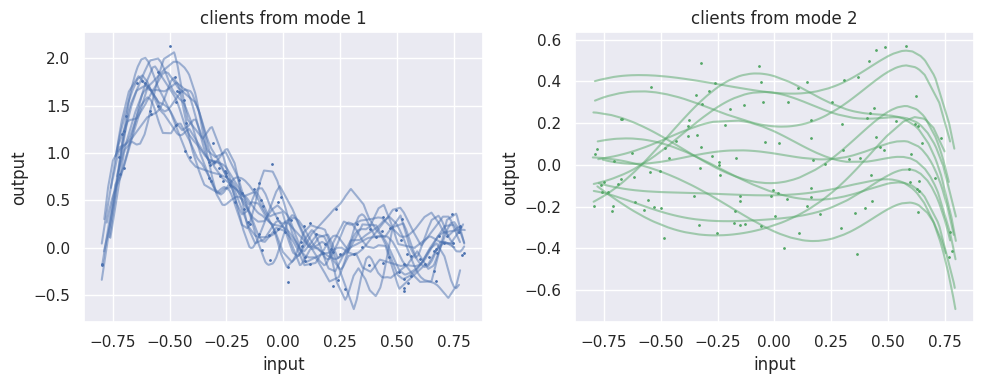

In [2]:
from experiments.data_sim import ToyDataset
num_clients=24
noise_std=0.1
weight_modes=[0.5, 0.5]
true_length_scales=[0.05, 0.5]

# define the environment
task_env = ToyDataset(
    noise_std=0.05, length_scales=true_length_scales, 
    mean_type='poly',random_state=random_state)

# generate data for existing client
clients_data, noise_free_data = task_env.generate_clients_data(
    num_clients=num_clients, n_train=100, 
    n_test=100, weight_modes=weight_modes)
# reduced size data for existing clients
inds = np.arange(10) # use only 10 training sampls
clients_data_sml = [(d[0][inds, :], d[1][inds,:], d[2], d[3]) for d in clients_data]

# data for new clients
clients_data_new, _ = task_env.generate_clients_data(
    num_clients=num_clients, n_train=100, 
    n_test=100, weight_modes=weight_modes)
clients_data_new = [tuple([dd[0:10, :] for dd in d]) for d in clients_data_new] # 10 training samples for each new client
num_clients_new = len(clients_data_new)


num_modes = 2
num_clients_per_mode = [int(weight_modes[0]*num_clients), num_clients-int(weight_modes[0]*num_clients)]

# plot the task environment
fig, axs = plt.subplots(1,2,figsize=(5*2,4))
client_num = 0
colors = ['b', 'g']
for mode_num in np.arange(num_modes):
    # client poly
    for i in np.arange(num_clients_per_mode[mode_num]):
        x_noisefree, y_noisefree = noise_free_data[client_num][2], noise_free_data[client_num][3]
        argsort = np.argsort(x_noisefree.flatten())
        x_noisefree = x_noisefree[argsort]
        y_noisefree = y_noisefree[argsort]
        axs[mode_num].plot(
            x_noisefree, y_noisefree, 
            c=colors[mode_num], alpha=0.5)
        # mark data
        if i>=0:
            axs[mode_num].scatter(
                clients_data_sml[client_num][0], clients_data_sml[client_num][1], 
                color=colors[mode_num], s=1)
        client_num=client_num+1
    
    axs[mode_num].set_title('clients from mode {:1.0f}'.format(mode_num+1))
    axs[mode_num].set_xlabel('input')
    axs[mode_num].set_ylabel('output')

plt.tight_layout()
save_fig = True
if save_fig:
    plt.savefig("ToyDataset.pdf", format="pdf", bbox_inches="tight")
plt.show()



# Setup 
Since the features are 1-dimensional in this example, we do not need to use a deep kernel and employ a SE kernel.
We fix the kernel outputscale to 1 but learn the lengthscale.
The hyper-prior over the lengthscale is a wide Gaussian with a relatively large mean to avoid over fitting.
We select the exact values for the hyper-prior mean and variance by plotting some candidates.



Note - learning positive hyper-parameters:
The kernel lengthscale and the lieklihood noise standard deviation must be positive. Similar to Gpytorch, we learn noise_std_raw and lengthscale_raw which are unconstrained, and then apply the Softplus funciotn on top of them to get a positive lengthscale and noise standard deviation. The hyper-prior is Gaussian over the raw values, not over the real ones.


In [3]:
criteria = ['rsmse', 'nll', 'calibr']       # NOTE: ideally, must pick the mean model accordingly
mean_nn_layers = [(int(n), int(n)) for n in np.logspace(1,4,4,base=2)]
methods_to_run = ['nn'+str(l[0])+'x'+str(len(l))+'_SE' for l in mean_nn_layers]
clients_subset = [1, 4, 15, 18]  


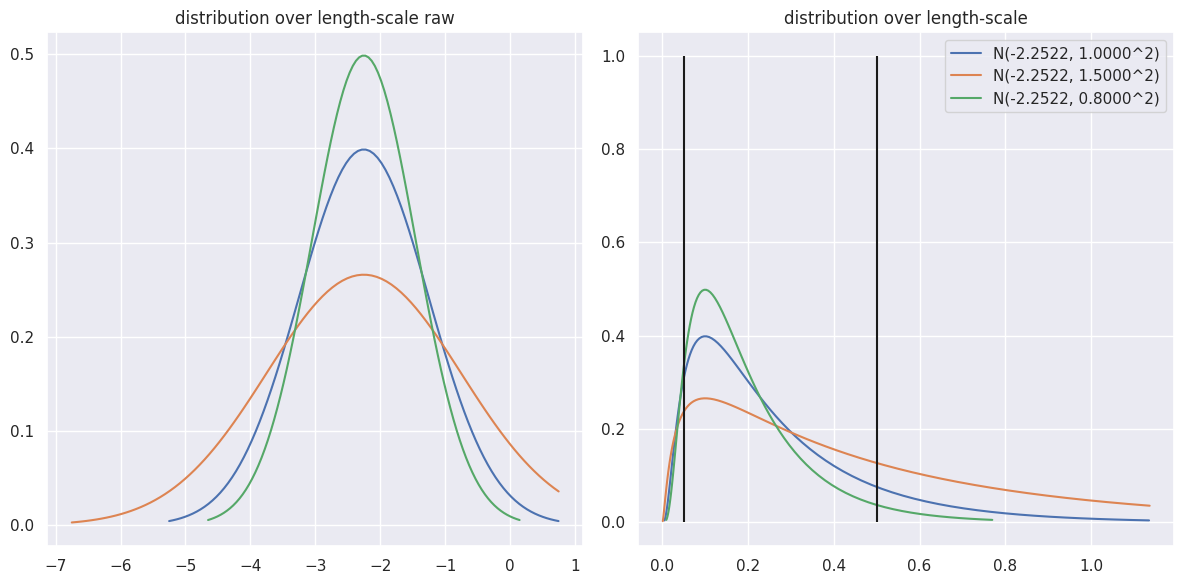

In [4]:
hyper_prior_dicts = []
for lengthscale_raw_loc in [softplus_inverse(0.1)]:
    for lengthscale_raw_scale in [1, 1.5, 0.8]:
        hyper_prior_dicts.append(
            {
            'lengthscale_raw_loc': lengthscale_raw_loc,
            'lengthscale_raw_scale': lengthscale_raw_scale, 
            }
        ) 


fig, axs = plt.subplots(1, 2, figsize=(12,6))

lscales = []
# oscales = []
for hyper_prior_dict in hyper_prior_dicts:
    mu = hyper_prior_dict['lengthscale_raw_loc']
    sigma = hyper_prior_dict['lengthscale_raw_scale']
    if not (mu, sigma) in lscales:
        x = np.linspace(
            mu - 3*sigma, 
            min(mu + 3*sigma, true_length_scales[1]*1.5), 
            100)
        axs[0].plot(x, stats.norm.pdf(x, mu, sigma), label='N({:2.4f}, {:2.4f}^2)'.format(mu,sigma))
        x = torch.tensor(x)
        axs[1].plot(
            F.softplus(x), stats.norm.pdf(x, mu, sigma), label='N({:2.4f}, {:2.4f}^2)'.format(mu,sigma), 
        )
        lscales.append((mu, sigma))
axs[1].vlines(true_length_scales[0], 0, 1, color='k') 
axs[1].vlines(true_length_scales[1], 0, 1, color='k') 
axs[0].set_title('distribution over length-scale raw')
axs[1].set_title('distribution over length-scale')
plt.legend()
plt.tight_layout()


In [ ]:
# set properties that are different based on the GP mean
options_base={
        # noise setup
        'optimize_noise':True, # NOTE
        'noise_std':None, 
        'likelihood_str': 'Gaussian',
        # linear model
        'covar_module_str': ['SE'], 'mean_module_str':['NN'], 
        'kernel_nn_layers': [], 'mean_nn_layers':[],
        'nonlinearity_output_m': None, 'nonlinearity_output_k': None,  
        'nonlinearity_hidden_m': torch.tanh, 'nonlinearity_hidden_k': None,
        'feature_dim':2, 
        'optimize_lengthscale': True, 'lengthscale_fix':None,
        # Configuration for GP-Prior learning
        'lr': 1e-2,            # initial learning rate for Adam optimizer'
        'lr_decay': 0.90,      # 'multiplicative learning rate decay factor applied after every 1000 steps'
        'task_batch_size': 5,  # number of clients for computing grads'
        'normalize_data': True, # NOTE
        # iterations
        'num_iter_fit': 800, # NOTE
        'max_iter_fit': 1000,
        'early_stopping': True,
        'n_threads': 8,
        # time-series prediction
        'ts_data':False
}

# options specific to our method
options_base['num_particles'] = 4 
options_base['bandwidth'] = -1        # heuristic lengthscale for SVGD heuristically            
# options_base['initial_particles'] = {'noise_raw': softplus_inverse(0.3)}

options = dict.fromkeys(methods_to_run)
for method, mean_nn_layer in zip(methods_to_run, mean_nn_layers):
        options[method] = copy.deepcopy(options_base)
        options[method].update({
                'mean_module_str':['NN'], 'mean_nn_layers':[mean_nn_layer],
        })
# models with mean and kernel
        # hyper-prior:
        options[method]['hyper_prior_dict'] = [
                {'lengthscale_raw_loc':softplus_inverse(0.1), 'lengthscale_raw_scale':1.5}]
        if options[method]['optimize_noise']:
                for d in options[method]['hyper_prior_dict']:
                        d.update(
                                {'outputscale_raw_loc':softplus_inverse(1), 'outputscale_raw_scale':0.01,
                                'noise_raw_loc': softplus_inverse(0.1), 
                                'noise_raw_scale': 0.1},
                        )
        else:
                options[method]['hyper_prior_dict'] = [{
                        'outputscale_raw_loc':softplus_inverse(1), 'outputscale_raw_scale':0.01
                }]

beta = clients_data[0][0].shape[0]


# 1. Vanilla
## 1.1 Vanilla nn16x2_SE
First, we fit a Vanilla model for two clients from different modes.
For each client, we once fit the model using 10 training samples and once using 100 training samples.
The model is a GP with a NN mean with 2 hidden layers and 16 neurone per hidden layer and an SE kernel (nn16x2_SE).


Observations:
* with 100 training samples, the Vanilla model works well for both clients,
* with 10 training samples, the Vanilla model performs poorly for both clients.


Conclusions:
* the nn16x2_SE is capable of capturing the patterns in the dataset of the two clients, when the each client has sufficiently enough data samples.


In [ ]:
run_cell = False
if run_cell:
    # plotting the task environment
    fig, axs = plt.subplots(2,2,figsize=(8*2,8))

    # plot modes
    for mode_num, client_num in zip([0,1], [2,22]):
        x_noisefree, y_noisefree = noise_free_data[client_num][2], noise_free_data[client_num][3]
        argsort = np.argsort(x_noisefree.flatten())
        x_noisefree = x_noisefree[argsort]
        y_noisefree = y_noisefree[argsort]
        for ind, num_samp in enumerate([10, 100]):
            ax = axs[ind][mode_num]
            ax.plot(x_noisefree, y_noisefree, c='r', alpha=0.5)
            # mark data
            ax.scatter(
                clients_data[client_num][0], clients_data[client_num][1], 
                color='r', label='true')


            data_tup = clients_data[client_num]
            inds = np.arange(num_samp)
            option_tmp = options[methods_to_run[-1]]
            option_tmp.update({'prior_factor':0})
            mdl, res =  find_best_model(
                [(data_tup[0][inds, :], data_tup[1][inds, :], data_tup[2], data_tup[3])], 
                random_seed, criteria=['rsmse'], 
                logger=None, # TODO
                pf_scheduler=None, # TODO
                mode='meta_fedavg', verbose=False, 
                options=option_tmp, initial_particles={}, log_period=50)

            y_pred_val = mdl['rsmse'].predict(data_tup[0][inds, :], data_tup[1][inds, :], data_tup[2])[0]
            ax.scatter(data_tup[2], y_pred_val, c='b', label='predicted')
            
            argsort = np.argsort(data_tup[2].flatten())
            ax.plot(data_tup[2][argsort], y_pred_val[argsort], c='b', alpha=0.5)

            ax.set_title('Client {:2.0f} from mode {:1.0f} - {:3.0f} samples'.format(client_num, mode_num+1, num_samp))
            ax.set_xlabel('inputs')
            ax.set_ylabel('outputs')
            ax.legend()
    plt.tight_layout()
    plt.show()

## 1.2 Vanilla vs sample size for different mean NN structures
To investigate the effect of clients training dataset size on the performance of the Vanilla model, we change the size of the training dataset and fit Vanilla GP models.
As observed in the previous part, the nn16x2_SE model performs poorly when the training datset is small. Therefore, we try other more simple models, namely nn2x2_SE, nn4x2_SE, nn8x2_SE, nn16x2_SE. We repeat the training for 2 clients from each mode. The results are saved and can be loaded.

In [ ]:
run_cell = False # rerun the models or load them
mode='vanilla'
# number of training samples to use
num_samp = np.logspace(
        np.log2(10), 
        np.log2(clients_data[0][0].shape[0]), 
        base=2, num=4, dtype=int)
num_samp[0] = 10
num_samp[-1] = clients_data[0][0].shape[0]

# ----- SET UP LOGGER -----
file_name_base = os.path.join(BASE_DIR, 'experiments', 'Toy_dataset', 'saved_results', )
filename_log  = os.path.join(file_name_base,'Vanilla') + "_log"
filename_save = os.path.join(file_name_base,'Vanilla') + "_res"

if run_cell:
        logging.basicConfig(filename=filename_log, format='%(asctime)s %(message)s', filemode='w')
        logger_vanilla=logging.getLogger('vanilla')
        logger_vanilla.setLevel(logging.DEBUG)
        logger_vanilla = WrapLogger(logger_vanilla)
        # initialize results
        results_all_clients=[None]*num_clients

        # train
        for client_ind, client_num in enumerate(clients_subset):
                logger_vanilla.info('\n\nClient {:2.0f}:'.format(client_num))
                results_all_clients[client_num] = dict.fromkeys(methods_to_run)
                data_tup = clients_data[client_num]
                # try different NN structures for the GP mean
                for method_to_run in methods_to_run:
                        err_vs_num_samp = np.zeros(len(num_samp))
                        logger_vanilla.info('\n---- '+method_to_run+' ----')
                        options[method_to_run]['prior_factor']=0
                        # change the number of training samples
                        for i, num_samples_tmp in enumerate(num_samp):
                                logger_vanilla.info('{:3.0f} samples'.format(num_samples_tmp))
                                inds = np.arange(num_samples_tmp)
                                option_tmp = options[method_to_run]
                                option_tmp.update({'prior_factor':0})
                                _, res = find_best_model(
                                        [(data_tup[0][inds, :], data_tup[1][inds, :], data_tup[2], data_tup[3])], 
                                        random_seed, criteria=['rsmse'], 
                                        logger=logger_vanilla, # NOTE
                                        pf_scheduler=None, #NOTE
                                        mode='meta_fedavg', verbose=False, 
                                        options=option_tmp, initial_particles={}, log_period=200)
                                err_vs_num_samp[i]= res['rsmse']['criterion_valid'][0]
                        results_all_clients[client_num][method_to_run] = err_vs_num_samp
        # save results
        file = open(filename_save, 'wb')
        pickle.dump(results_all_clients, file)
        file.close()
else:
        # load results
        file = open(filename_save, 'rb')
        results_all_clients = pickle.load(file)
        file.close()
                                                

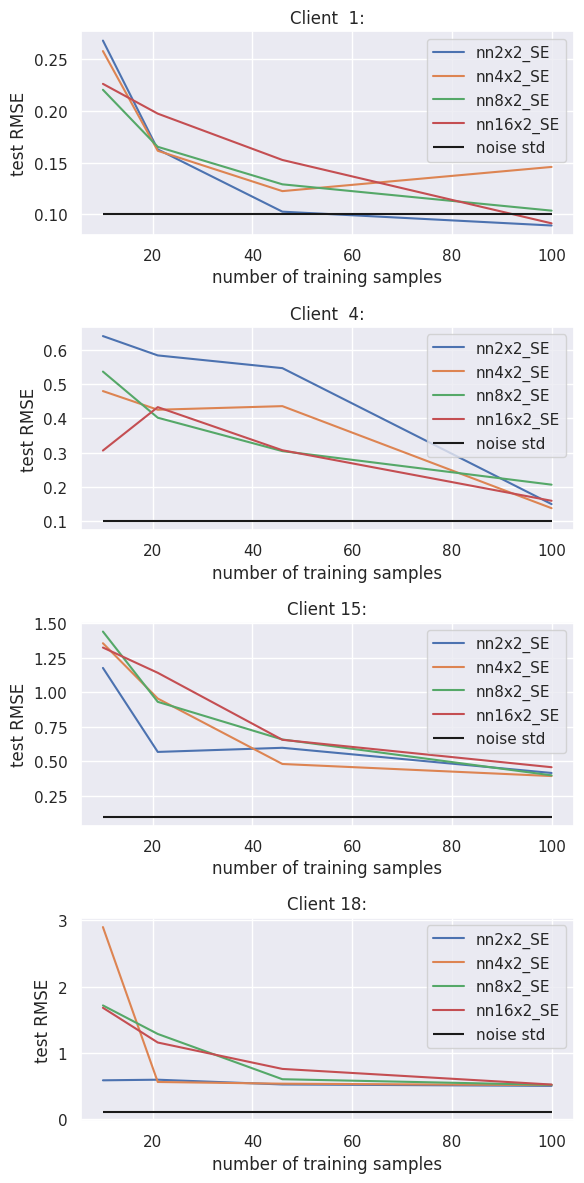

In [ ]:
# plot Vanilla vs sample size for different methods
fig, axs = plt.subplots(len(clients_subset), 1, figsize = (6,3*len(clients_subset)))
for client_ind, client_num in enumerate(clients_subset):
        ax = axs[client_ind]
        for method_to_run in methods_to_run:
                if not method_to_run in results_all_clients[client_num].keys():
                        print('[WARN] please run ' + method_to_run + 'first.')
                        continue
                err_vs_num_samp = results_all_clients[client_num][method_to_run]
                ax.plot(num_samp, err_vs_num_samp, label=method_to_run)
        ax.hlines(y = noise_std, xmin = num_samp[0], xmax = num_samp[-1], label='noise std', color='k')
        ax.set_title('Client {:2.0f}:'.format(client_num))
        ax.set_xlabel('number of training samples')
        ax.set_ylabel('test RMSE')
        ax.legend()
plt.tight_layout()
plt.show()

## 1.3 Vanilla with 10 samples for all clients
As was demonstrated on a subset of 6 clients, 10 training samples is not enough for fitting the Vanilla model. 

In [ ]:
run_cell = False
run_only_best = False
methods_to_run_vanilla = ['nn2x2_SE'] if run_only_best else methods_to_run
filename = os.path.join(
    file_name_base,
    'Vanilla_sml_all_clients_' + ('best' if run_only_best else 'allmodels')
) 
filename_log, filename_save = filename + "_log", filename  + "_res"  

if run_cell:
    # 1. init
    logging.basicConfig(filename=filename_log, format='%(asctime)s %(message)s', filemode='w')
    logger_vanilla_sml=logging.getLogger('vanilla_sml')
    logger_vanilla_sml.setLevel(logging.DEBUG)
    logger_vanilla_sml = WrapLogger(logger_vanilla_sml)
    results_vanilla_sml=[None]*num_clients
    models_vanilla_sml=[None]*num_clients

    # 2. train for all clients
    for client_num in np.arange(num_clients):
        best_rsmse = 1e6
        logger_vanilla_sml.info('\n\nClient {:2.0f}:'.format(client_num))
        results_vanilla_sml[client_num] = dict.fromkeys(methods_to_run_vanilla)
        data_tup = clients_data_sml[client_num]
        for method_to_run in methods_to_run_vanilla:
            logger_vanilla_sml.info('---- '+method_to_run+' ----')
            option_tmp = options[method_to_run]
            option_tmp.update({'prior_factor':0})
            mdl, _ = find_best_model(
                [data_tup], random_seed, criteria=['rsmse'], 
                logger=logger_vanilla_sml, pf_scheduler=None,
                mode='meta_fedavg', verbose=False, 
                options=option_tmp, log_period=200)
            # 3. eval
            results_vanilla_sml[client_num][method_to_run] = mdl['rsmse'].eval_datasets(
                [data_tup])
            # 4.compare
            if results_vanilla_sml[client_num][method_to_run]['rsmse'] < best_rsmse:
                models_vanilla_sml[client_num] = method_to_run
                best_rsmse = results_vanilla_sml[client_num][method_to_run]['rsmse']
        # logger_vanilla_sml.info('lowest rsmse : {:2.6f}'.format(min([r for r in results_vanilla_sml[client_num].values()])))
    
    # 5. new clients
    results_vanilla_new = [None]*num_clients_new
    for client_num in np.arange(num_clients_new):
        logger_vanilla_sml.info('\n\nNew client {:2.0f}:'.format(client_num))
        data_tup = clients_data_new[client_num]
        option_tmp = options['nn2x2_SE']
        option_tmp.update({'prior_factor':0})
        mdl, _ = find_best_model(
            [data_tup], random_seed, criteria=['rsmse'], 
            logger=logger_vanilla_sml, pf_scheduler=None,
            mode='meta_fedavg', verbose=False, 
            options=option_tmp, log_period=200)
        results_vanilla_new[client_num] = mdl['rsmse'].eval_datasets([data_tup])

    # 6. print info for the best method
    logger_vanilla_sml.info('RSMSE and CE mean for existing clients: {:1.3f}, {:1.3f}'.format(
        np.mean(np.array(
            [results_vanilla_sml[client_num]['nn2x2_SE']['rsmse'] for client_num in np.arange(num_clients)]
        )),
        np.mean(np.array(
            [results_vanilla_sml[client_num]['nn2x2_SE']['calibr'] for client_num in np.arange(num_clients)]
        ))
    ))
    logger_vanilla_sml.info('RSMSE and CE mean for new clients: {:1.3f}, {:1.3f}'.format(
        np.mean(np.array(
            [results_vanilla_new[client_num]['rsmse'] for client_num in np.arange(num_clients_new)]
        )),
        np.mean(np.array(
            [results_vanilla_new[client_num]['calibr'] for client_num in np.arange(num_clients_new)]
        ))
    ))

    # 7. save
    file = open(filename_save, 'wb')
    pickle.dump(
        {'existing':results_vanilla_sml, 'new': results_vanilla_new}, 
        file
    )
    file.close()
else:
    # load
    file = open(filename_save, 'rb')
    res = pickle.load(file)
    results_vanilla_sml = res['existing']
    file.close()
  
'''
Results for running with random_seeds 5, 10, 15, 20, 25
RSMSE existing = [0.703, 0.681, 0.747, 0.724, 0.779]
CE existing =    [0.169, 0.186, 0.177, 0.177, 0.183]
RSMSE new =      [0.787, 0.742, 0.730, 0.789, 0.765]
CE new =         [0.209, 0.227, 0.248, 0.257, 0.243]
'''                       
                                        

'\nResults for running with random_seeds 5, 10, 15, 20, 25\nRSMSE existing = [0.703, 0.681, 0.747, 0.724, 0.779]\nCE existing =    [0.169, 0.186, 0.177, 0.177, 0.183]\nRSMSE new =      [0.787, 0.742, 0.730, 0.789, 0.765]\nCE new =         [0.209, 0.227, 0.248, 0.257, 0.243]\n'

[WARNING] FixedFormatter should only be used together with FixedLocator UserWarning
in file/tmp/ipykernel_829252/1653693633.py at line number:39
[WARNING] FixedFormatter should only be used together with FixedLocator UserWarning
in file/tmp/ipykernel_829252/1653693633.py at line number:39


[WARNING] FixedFormatter should only be used together with FixedLocator UserWarning
in file/tmp/ipykernel_829252/1653693633.py at line number:39[WARNING] FixedFormatter should only be used together with FixedLocator UserWarning
in file/tmp/ipykernel_829252/1653693633.py at line number:39

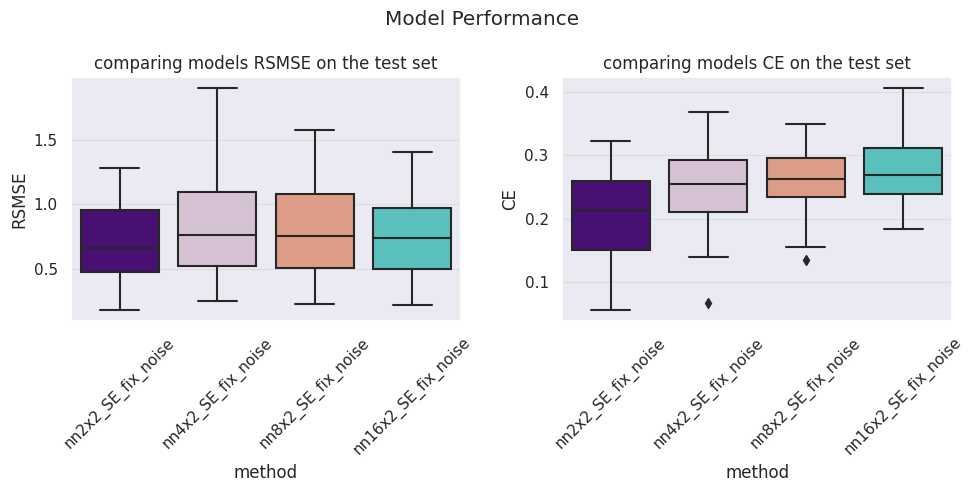

,method,RSMSE_mean,RSMSE_min,RSMSE_max,RSMSE_median
0,nn16x2_SE_fix_noise,0.763147,0.222723,1.403626,0.742679
1,nn2x2_SE_fix_noise,0.709860,0.179270,1.280018,0.660510
2,nn4x2_SE_fix_noise,0.835784,0.252173,1.897572,0.762828
3,nn8x2_SE_fix_noise,0.798252,0.230141,1.579052,0.752955


In [ ]:
import pandas as pd
import matplotlib.colors as mcolors

# plot
methods = list(results_vanilla_sml[0].keys())
num_rows = num_clients * len(methods)
res_df = {
    'client_num': np.zeros(num_rows), 
    'RSMSE': np.zeros(num_rows),
    'CE': np.zeros(num_rows),
    'method':[None]*num_rows}
n=0
for method in methods:
    for client_num in np.arange(num_clients):
        res_df['client_num'][n] = client_num
        res_df['method'][n] = method 
        r = results_vanilla_sml[client_num][method]
        res_df['RSMSE'][n] = r['rsmse']
        res_df['CE'][n] = r['calibr']
        n +=1

res_df = pd.DataFrame(data=res_df)

# plot
plot_title = 'Model Performance' 
fig, axs = plt.subplots(1, 2, sharey=False, figsize=(10,5))
fig.subplots_adjust(left=0.075, right=0.95, top=0.9, bottom=0.25)
random.seed(3)
colors = random.sample(sorted(mcolors.CSS4_COLORS), len(methods))
for ax, criterion in zip(axs, ['RSMSE', 'CE']):
    ax.yaxis.grid(True, linestyle='-', which='major', color='lightgrey',
                alpha=0.5)
    ax.set(
        axisbelow=True,  # Hide the grid behind plot objects
        title='comparing models ' + criterion + ' on the test set',
        xlabel='method', 
        ylabel=criterion,
    )
    ax.set_xticklabels(res_df['method'], rotation=45)
    sns.boxplot(y=criterion, x='method',
                data=res_df,
                palette=colors,
                #hue='method',
                ax=ax)

fig.suptitle(plot_title)
plt.tight_layout()
plt.show()

# print stats
stats_df = res_df.groupby(['method']).agg(
    {'RSMSE': ['mean', 'min', 'max', 'median']})
stats_df.columns = ['RSMSE' + '_' + x for x in ['mean', 'min', 'max', 'median']]
stats_df = stats_df.reset_index()
stats_df.style.highlight_min(color='lightgreen', axis=0)



# 2. PAC-PFL with 10 samples per client

In [ ]:
# use 10 training samples per client
run_cell = False
methods_to_run_PACPFL = ['nn16x2_SE']

run_only_best = True
if run_only_best:
        pf_scheduler = PriorFactorScheduler(
        method='grid', num=5, space='lin', 
        pf_range=(0.3, 0.5),
        test_no_regul=False, init_step_size=None, 
        early_stopping=True, thresh=0.025,
        check_of_any=False # enough not to over-fit on average
        )
else:
        pf_scheduler = PriorFactorScheduler(
                method='grid', num=10, space='lin', 
                pf_range=(1e-1, 1),
                test_no_regul=False, init_step_size=None, 
                early_stopping=True, thresh=0.025,
                check_of_any=False # enough not to over-fit on average
                )
filename_log  = os.path.join(file_name_base,'PAC-PFL' + ('best' if run_only_best else 'allmodels')) + "_log"  
filename_save = os.path.join(file_name_base,'PAC-PFL' + ('best' if run_only_best else 'allmodels')) + "_res"  

if run_cell:
        # ----- SET UP LOGGER -----
        logging.basicConfig(filename=filename_log, format='%(asctime)s %(message)s', filemode='w')
        logger_PACPFL=logging.getLogger('PAC-PFL')
        logger_PACPFL.setLevel(logging.DEBUG)
        logger_PACPFL = WrapLogger(logger_PACPFL)
        results = dict.fromkeys(methods_to_run_PACPFL)
        results_new = dict.fromkeys(methods_to_run_PACPFL)
        models = dict.fromkeys(methods_to_run_PACPFL)
        models_srz = dict.fromkeys(methods_to_run_PACPFL)
        # train
        options_tmp=options[method_to_run]
        options_tmp.update({
                'num_iter_fit': 2500, 'max_iter_fit': 3000,
        })
        for method_to_run in methods_to_run_PACPFL:
                models[method_to_run], _ = find_best_model(
                        clients_data_sml, 
                        random_seed, criteria=['rsmse'], 
                        logger=logger_PACPFL, 
                        pf_scheduler=pf_scheduler,
                        mode='ours', verbose=True, 
                        options=options_tmp, log_period=200)
                models[method_to_run] = models[method_to_run]['rsmse']
                # compress models
                models_srz[method_to_run] = serialize_model(
                        models[method_to_run],
                        normalize_data=options[method_to_run]['normalize_data'],
                        random_seed=random_seed)
                # eval
                results[method_to_run] = models[method_to_run].eval_datasets(clients_data_sml)
                results_new[method_to_run] = models[method_to_run].eval_datasets(clients_data_new)
                # print info:
                logger_PACPFL.info('RSMSE and CE for existing clients: {:1.3f}, {:1.3f}'.format(
                        results[method_to_run]['rsmse'], results[method_to_run]['calibr']
                ))
                logger_PACPFL.info('RSMSE and CE for new clients: {:1.3f}, {:1.3f}'.format(
                        results_new[method_to_run]['rsmse'], results_new[method_to_run]['calibr']
                ))
        # save results and models
        file = open(filename_save, 'wb')
        pickle.dump({'models':models_srz, 'results':results, 'results_new':results_new}, file)
        file.close()
else:
        # load results and models
        file = open(filename_save, 'rb')
        r = pickle.load(file)
        file.close()
        models, results, results_new = r['models'], r['results'], r['results_new']


'''
Results for running with random_seeds 5, 10, 15, 20, 25
RSMSE existing = [0.587, 0.589, 0.619, 0.546, 0.567]
CE existing =    [0.140, 0.140, 0.141, 0.153, 0.126]
RSMSE new =      [0.646, 0.654, 0.643, 0.675, 0.642]
CE new =         [0.167, 0.158, 0.163, 0.171, 0.166]
'''   

'\nResults for running with random_seeds 5, 10, 15, 20, 25\nRSMSE existing = [0.587, 0.589, 0.619, 0.546, 0.567]\nCE existing =    [0.140, 0.140, 0.141, 0.153, 0.126]\nRSMSE new =      [0.646, 0.654, 0.643, 0.675, 0.642]\nCE new =         [0.167, 0.158, 0.163, 0.171, 0.166]\n'

# 3. MAML

In [ ]:
run_cell = False
methods_MAML = ['nn'+str(int(n))+'x2' for n in np.logspace(1,7,num=7,base=2)]

if run_cell:
    run_only_best = True
    if run_only_best: 
        methods_MAML = ['nn64x2']
    # 1. init
    models_MAML = dict.fromkeys(methods_MAML)
    results_MAML = dict.fromkeys(methods_MAML)
    meta_train_data = []
    for client_num in np.arange(num_clients):
        meta_train_data.append((clients_data_sml[client_num][0], clients_data_sml[client_num][1]))
    
    # 2. train
    best_rsmse = 1e6
    for method in methods_MAML:
        print('\n' + method)
        num_layers = int(method.split('x')[-1])
        num_neurons = int(method.split('x')[0][2:])
        layer_sizes = (num_neurons,)*num_layers
        maml_model = MAMLRegression(
            meta_train_data, task_batch_size=5, num_iter_fit=2500, layer_sizes=layer_sizes)
        maml_model.meta_fit(clients_data_sml, log_period=500)
        # 3. eval
        results_MAML[method] = maml_model.eval_datasets(clients_data_sml, get_full_list=True)['rsmse']
        # 4. compare
        if np.mean(np.array(results_MAML[method]))<best_rsmse:
            best_rsmse = np.mean(np.array(results_MAML[method]))
            best_method = method
            best_maml_model = maml_model
    print('\n\nThe best MAML model is ' + best_method)
    print('RSMSE for existing clients = {:1.6f}'.format(best_rsmse))

    # 5. new clients for the best model
    meta_train_data_new = []
    for client_num_new in np.arange(num_clients_new):
        meta_train_data_new.append(
            (clients_data_new[client_num_new][0], clients_data_new[client_num_new][1])
        )
    # eval
    results_MAML_new = best_maml_model.eval_datasets(clients_data_new, get_full_list=False)['rsmse']
    print('RSMSE for new clients = {:1.6f}'.format(results_MAML_new))

'''
Results for running with random seeds 5, 10, 15, 20, 25
RSMSE for existing clients = [0.858725, 0.984337, 1.058250, 0.970084, 1.007143]
RSMSE for new clients =      [0.884075, 1.217413, 0.983936, 1.220709, 1.229120]
'''

'\nResults for running with random seeds 5, 10, 15, 20, 25\nRSMSE for existing clients = [0.858725, 0.984337, 1.058250, 0.970084, 1.007143]\nRSMSE for new clients =      [0.884075, 1.217413, 0.983936, 1.220709, 1.229120]\n'

# 4. MTL

In [ ]:
from server.MTL_server import *
from baselines.MTL.household import *

run_cell = False
if run_cell:
    # search space
    models_MTL = {'trained_lambda':None, 'trained_w_0':None}

    log_lambdas = np.linspace(-3, 3, 40)
    lambdas = pow(10, log_lambdas)
    lr=0.1
    inner_iters=1
    outer_iters=100
    valid_frac=0.2


    # 1. define households
    clients_data = clients_data_sml
    clients_ts = clients_data_sml
    households = []
    for client_num in np.arange(num_clients):
        h = Household(
            clients_data[client_num], clients_ts[client_num], normalize_data=True, random_seed=random_seed)
        h.train_valid_split(valid_frac=valid_frac)
        households.append(h)


    # 2. initialize 
    rsmse_w_n_trn = np.zeros((len(households), len(lambdas)))
    rsmse_w_n_vld = np.zeros((len(households), len(lambdas)))
    rsmse_w_n_tst = np.zeros((len(households), len(lambdas)))

    # 3. grid search lambda
    min_rsmse_vld = 1e4
    for l_ind, lambda_ in enumerate(lambdas): 
        # train
        result = mtl_train(
            households, lr=lr, lambda_=lambda_, 
            inner_iters=inner_iters, outer_iters=outer_iters, 
            optim_method='Adam', verbose=False, priv=False,
            random_seed=random_seed)
        w_0=result['w_0']
        init_state_dict=result['init_state_dicts']
        # predict
        for h_ind, household in enumerate(households): 
            # predict with w_n 
            pred_w_n_trn = household.predict(household.X_train, method='MTL').flatten()
            pred_w_n_vld = household.predict(household.X_valid,  method='MTL').flatten()
            pred_w_n_tst = household.predict(household.X_test,  method='MTL').flatten()

            # errors of w_n
            rsmse_w_n_trn[h_ind, l_ind] = (np.mean(
                    (pred_w_n_trn-household.y_train.detach().numpy().flatten())**2
                )**0.5)/np.std(household.y_train.detach().numpy().flatten())
            rsmse_w_n_vld[h_ind, l_ind] = (
                    np.mean((pred_w_n_vld-household.y_valid.detach().numpy().flatten())**2
                )**0.5)/np.std(household.y_valid.detach().numpy().flatten())
            rsmse_w_n_tst[h_ind, l_ind] = (
                    np.mean((pred_w_n_tst-household.y_test.detach().numpy().flatten())**2
                )**0.5)/np.std(household.y_test.detach().numpy().flatten())
            
        # update best_w_0
        if np.mean(rsmse_w_n_vld[:, l_ind].flatten()) < min_rsmse_vld:
            min_rsmse_vld = np.mean(rsmse_w_n_vld[:, l_ind].flatten())
            models_MTL['trained_w_0'] = w_0
            models_MTL['trained_lambda'] = lambdas[l_ind]


    # 4. compute error metrics
    rsmse_w_n_trn_av = np.mean(rsmse_w_n_trn, axis=0)
    rsmse_w_n_vld_av = np.mean(rsmse_w_n_vld, axis=0)
    rsmse_w_n_tst_av = np.mean(rsmse_w_n_tst, axis=0)
    rsmse_w_n_trn_sd = np.var(rsmse_w_n_trn, axis=0)**0.5
    rsmse_w_n_vld_sd = np.var(rsmse_w_n_vld, axis=0)**0.5
    rsmse_w_n_tst_sd = np.var(rsmse_w_n_tst, axis=0)**0.5


    # 5. Plot
    xx = log_lambdas
    fig,axs = plt.subplots(3,1,figsize=(6,6))
    axs[0].scatter(xx, rsmse_w_n_trn_av, color='orange', label='w_n')
    axs[0].set_title('Train')
    axs[2].scatter(xx, rsmse_w_n_vld_av, color='orange', label='w_n')
    axs[2].set_title('Valid')
    axs[1].scatter(xx, rsmse_w_n_tst_av, color='orange', label='w_n')
    axs[1].set_title('Test')
    for ax in axs:
        ax.legend()
        ax.set_xlabel('log(lambda)')
        ax.set_ylabel('RSMSE over households')
    plt.tight_layout()
    plt.show()


    # 6. best lambda
    best_l_ind = np.argmin(rsmse_w_n_vld_av)
    assert models_MTL['trained_lambda'] == lambdas[best_l_ind]


    # 7. results
    results_MTL = np.array(rsmse_w_n_tst[:, best_l_ind].flatten())
    print('average performance on the test set for existing clients = {:1.3f}'.format(
        np.mean(results_MTL)
    )) 


    # 8. new clients
    households_new = []
    for client_num in np.arange(24):
        h = Household(
            clients_data_new[client_num], clients_data_new[client_num], 
            normalize_data=True, random_seed=random_seed
        )
        h.train_valid_split(valid_frac=0.2)
        households_new.append(h)
    # train
    mtl_employ(
        households_new, lr=lr, num_iters=inner_iters*outer_iters, 
        trained_lambda=models_MTL['trained_lambda'], 
        trained_w_0=models_MTL['trained_w_0'],
        random_seed=random_seed
    )
    # evaluate
    results_new = np.zeros(len(households_new))
    for h_ind, household in enumerate(households_new): 
        # predict with w_n 
        pred_w_n_trn = household.predict(household.X_train, method='MTL').flatten()
        pred_w_n_vld = household.predict(household.X_valid,  method='MTL').flatten()
        pred_w_n_tst = household.predict(household.X_test,  method='MTL').flatten()
        rsmse_trn = (np.mean((pred_w_n_trn-household.y_train.detach().numpy().flatten())**2
            )**0.5)/np.std(household.y_train.detach().numpy().flatten())
        rsmse_vld = (np.mean((pred_w_n_vld-household.y_valid.detach().numpy().flatten())**2
            )**0.5)/np.std(household.y_valid.detach().numpy().flatten())
        rsmse_tst = (np.mean((pred_w_n_tst-household.y_test.detach().numpy().flatten())**2
            )**0.5)/np.std(household.y_test.detach().numpy().flatten())

        results_new[h_ind] = rsmse_tst

    print('average performance on the test set for existing clients = {:1.3f}'.format(
        np.mean(results_new)
    )) 

'''
Results for running over random seeds 5, 10, 15, 20, 25
Existing clients: [0.997, 0.827, 0.788, 0.791, 0.853]
New clients:      [0.986, 0.797, 0.849, 0.909, 0.884]
'''         


'\nResults for running over random seeds 5, 10, 15, 20, 25\nExisting clients: [0.997, 0.827, 0.788, 0.791, 0.853]\nNew clients:      [0.986, 0.797, 0.849, 0.909, 0.884]\n'

# 5. Pooled

In [ ]:
from config import device
from server.abstract import _calib_error
from server.pooled_server import PooledGPModel
from torch.utils.data import TensorDataset, DataLoader
filename_log  = os.path.join(file_name_base,'Pooled') + "_log"  

run_cell = False
if run_cell:
    logging.basicConfig(filename=filename_log, format='%(asctime)s %(message)s', filemode='w')
    logger_pooled=logging.getLogger('pooled')
    logger_pooled.setLevel(logging.DEBUG)
    logger_pooled = WrapLogger(logger_pooled)
    
    # 1. prepare the data
    num_samples = clients_data_sml[0][0].shape[0]
    num_samples_test = clients_data_sml[0][2].shape[0]
    num_features = 1
    # augment data
    train_x = np.zeros((num_samples*num_clients, num_features))
    train_y = np.zeros((num_samples*num_clients))
    test_x = np.zeros((num_samples_test*num_clients, num_features))
    test_y = np.zeros((num_samples_test*num_clients))
    for client_num in np.arange(num_clients):
        train_x[num_samples*client_num:num_samples*(client_num+1), :] = clients_data_sml[client_num][0]
        train_y[num_samples*client_num:num_samples*(client_num+1)] = clients_data_sml[client_num][1].flatten()
        test_x[num_samples_test*client_num:num_samples_test*(client_num+1), :] = clients_data_sml[client_num][2]
        test_y[num_samples_test*client_num:num_samples_test*(client_num+1)] = clients_data_sml[client_num][3].flatten()
    # normalize using the statistics on train data
    train_y, test_y = train_y.reshape(-1,1), test_y.reshape(-1,1)
    x_mean, y_mean = np.mean(train_x, axis=0), np.mean(train_y, axis=0)
    x_std, y_std = np.std(train_x, axis=0) + 1e-8, np.std(train_y, axis=0) + 1e-8
    train_x = (train_x - x_mean[None, :]) / x_std[None, :]
    train_y = ((train_y - y_mean[None, :]) / y_std[None, :]).flatten()
    test_x = (test_x - x_mean[None, :]) / x_std[None, :]
    test_y = ((test_y - y_mean[None, :]) / y_std[None, :]).flatten()
    # to tensor
    train_x = torch.from_numpy(train_x).to(device).float()    
    train_y = torch.from_numpy(train_y).to(device).float()  
    test_x = torch.from_numpy(test_x).to(device).float()  
    test_y = torch.from_numpy(test_y).to(device).float()  
    # data loader
    train_loader = DataLoader(
        TensorDataset(train_x, train_y), batch_size=1024, shuffle=True)
    test_loader = DataLoader(
        TensorDataset(test_x, test_y), batch_size=1024, shuffle=False)


    # 2. train the pooled model
    run_only_best = True # specify only one model to run 
    num_epochs = 1500
    num_inducing_points = min(500, num_samples*num_clients)
    methods_to_run_pooled = ['nn16x2_SE'] if run_only_best else methods_to_run

    results_pooled = dict.fromkeys(methods_to_run)
    best_rsmse = 1e6
    for method in methods_to_run_pooled:
        logger_pooled.info('\n'+ method)
        results_pooled[method] = dict.fromkeys(['rsmse', 'calibr'])
        # ---- 1. initialize the model ----
        inducing_points = train_x[random_state.choice(
                np.arange(train_x.shape[0]), size=num_inducing_points, replace=False
        ), :]
        model = PooledGPModel(
            inducing_points=inducing_points, 
            mean_module_str='NN', covar_module_str='SE', 
            mean_nn_layers=(int(method.split('x')[0][2:]), )*2, 
            feature_dim=2
        ).to(device)
        likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
        # ---- 2. train the model ----
        model.train()
        likelihood.train()
        params_to_opt = model.shared_parameters + [
            {'params': likelihood.parameters()},
        ]
        optimizer = torch.optim.Adam(params_to_opt, lr=0.01)
        mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=train_y.size(0))
        for epoch_num in np.arange(num_epochs):
            for x_batch, y_batch in train_loader:
                optimizer.zero_grad()
                output = model(x_batch)
                loss = -mll(output, y_batch)
                loss.backward()
                optimizer.step()
                if epoch_num%200==0:
                    logger_pooled.info('iter {:5.0f} - loss {:2.4f}'.format(epoch_num, loss.item()))
        # ---- 3. predict and eval ----
        model.eval()
        likelihood.eval()
        # ---- 3.a predict ----
        means = torch.tensor([0.]).to(device)
        stddevs = torch.tensor([0.]).to(device)
        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                preds = model(x_batch)
                means = torch.cat([means, preds.mean]) # .cpu()
                stddevs = torch.cat([stddevs, preds.stddev]) # .cpu()
        means = means[1:]
        stddevs = stddevs[1:]
        # print(means.shape, stddevs.shape)
        # ---- 3.b eval ----
        rsmse_all = torch.zeros(num_clients)
        ce_all = torch.zeros(num_clients)
        n_st = 0
        for client_num in np.arange(num_clients):
            n_en = n_st+clients_data[client_num][2].shape[0]
            inds = np.arange(n_st, n_en)
            test_y_cl = test_y[inds]
            n_st = n_en
            # RSMSE
            rsmse_all[client_num] = torch.sqrt(torch.mean(
                (means[inds] - test_y_cl)**2))/torch.std(test_y_cl)
            # calibr
            pred_dist_vect = torch.distributions.Normal(means[inds], stddevs[inds])
            ce_all[client_num] = _calib_error(pred_dist_vect, test_y_cl)
        assert n_en == len(means)
        results_pooled[method]['rsmse'] = rsmse_all
        results_pooled[method]['calibr'] = ce_all
        logger_pooled.info('\n---- results with random seed  = {:2.0f} ----'.format(random_seed))
        logger_pooled.info('RSMSE = {:1.6f}'.format(torch.mean(rsmse_all)))
        logger_pooled.info('CE = {:1.6f}'.format(torch.mean(ce_all)))
        
        # 4. best method
        if torch.mean(rsmse_all) < best_rsmse:
            best_rsmse = torch.mean(rsmse_all)
            best_met = method
            best_model = model
    logger_pooled.info('\n\n\nBest method is: '+ best_met)

    # 5. new clients
    model.eval()
    likelihood.eval()
    num_clients_new = len(clients_data_new)
    rsmse_new = torch.zeros(num_clients_new)
    ce_new = torch.zeros(num_clients_new)
    pred_means = [None]*num_clients_new
    pred_stds = [None]*num_clients_new

    for client_num_new in np.arange(num_clients_new):
        train_x, train_y, test_x, test_y = clients_data_new[client_num_new]
        # normalize
        train_x = (train_x - x_mean[None, :]) / x_std[None, :]
        train_y = (train_y - y_mean[None, :]) / y_std[None, :].flatten()
        test_x = (test_x - x_mean[None, :]) / x_std[None, :]
        test_y = (test_y - y_mean[None, :]) / y_std[None, :].flatten()
        # to tensor
        train_x = torch.from_numpy(train_x).to(device).float()    
        train_y = torch.from_numpy(train_y).to(device).float()  
        test_x = torch.from_numpy(test_x).to(device).float()  
        test_y = torch.from_numpy(test_y).to(device).float()  
        # predict on the validation set
        with torch.no_grad():
            preds = best_model(test_x)
            # RSMSE
            rsmse_new[client_num_new] = torch.sqrt(torch.mean(
                (preds.mean.flatten() - test_y.flatten())**2))/torch.std(test_y)
            # calibr
            pred_dist_vect = torch.distributions.Normal(preds.mean.flatten(), preds.stddev.flatten())
            ce_new[client_num_new] = _calib_error(pred_dist_vect, test_y.flatten())
            pred_means[client_num_new] = preds.mean.detach().cpu().numpy()
            pred_stds[client_num_new] = preds.stddev.detach().cpu().numpy()

    logger_pooled.info('RSMSE new = {:1.6f}'.format(torch.mean(rsmse_new)))
    logger_pooled.info('CE new = {:1.6f}'.format(torch.mean(ce_new)))


'''
Results for running with random_seeds 5, 10, 15, 20, 25
RSMSE existing = [1.964298, 2.186693, 2.180395, 2.663440, 2.645181]
CE existing =    [0.311395, 0.309131, 0.312407, 0.347345, 0.349538]
RSMSE new =      [2.633183, 2.449920, 2.168605, 2.176567, 2.176011]
CE new =         [0.377536, 0.355652, 0.353299, 0.345999, 0.346048]
'''
    

'\nResults for running with random_seeds 5, 10, 15, 20, 25\nRSMSE existing = [1.964298, 2.186693, 2.180395, 2.663440, 2.645181]\nCE existing =    [0.311395, 0.309131, 0.312407, 0.347345, 0.349538]\nRSMSE new =      [2.633183, 2.449920, 2.168605, 2.176567, 2.176011]\nCE new =         [0.377536, 0.355652, 0.353299, 0.345999, 0.346048]\n'

# 6. pFedGP

In [ ]:
run_cell = False

filename_log  = os.path.join(file_name_base,'pFedGP') + "_log"  
filename_save = os.path.join(file_name_base,'pFedGP') + "_res"  

if run_cell:
    run_only_best = True
    methods_to_run_pFedGP = ['nn16x2_SE_fix_noise'] if run_only_best else methods_to_run

    # 1. init
    best_rsmse = 1e6
    logging.basicConfig(filename=filename_log, format='%(asctime)s %(message)s', filemode='w')
    logger_pFedGP=logging.getLogger('pFedGP')
    logger_pFedGP.setLevel(logging.DEBUG)
    logger_pFedGP = WrapLogger(logger_pFedGP)
    results_pFedGP=dict.fromkeys(methods_to_run)
    models_pFedGP=dict.fromkeys(methods_to_run)

    # 2.train 
    for method_to_run in methods_to_run_pFedGP:
        logger_pFedGP.info('---- '+method_to_run+' ----')
        option_tmp = options[method_to_run]
        option_tmp.update({
            'prior_factor':0, 'num_iter_fit': 2500, 'max_iter_fit': 3000,
        })
        mdl, _ = find_best_model(
            clients_data_sml, random_seed, criteria=['rsmse'], 
            logger=logger_pFedGP, pf_scheduler=None,
            mode='meta_fedavg', verbose=True, 
            options=option_tmp, log_period=200)
        
        # 3. eval
        results_pFedGP[method_to_run] = mdl['rsmse'].eval_datasets(
            clients_data_sml, get_full_list=False)
        models_pFedGP[method_to_run] = mdl['rsmse']

        # 4. comapre
        if results_pFedGP[method_to_run]['rsmse'] < best_rsmse:
            best_rsmse = results_pFedGP[method_to_run]['rsmse']
            best_model = models_pFedGP[method_to_run]
            best_method = method_to_run

    logger_pFedGP.info('\n\nBest method is ' + best_method)
    logger_pFedGP.info('Mean RSMSE for existing clients = {:1.6f}'.format(best_rsmse))
    logger_pFedGP.info('Mean CE for existing clients = {:1.6f}'.format(results_pFedGP[best_method]['calibr']))

    # 5. new clients
    res_new = best_model.eval_datasets(clients_data_new)
    logger_pFedGP.info('Mean RSMSE for new clients = {:1.6f}'.format(res_new['rsmse']))
    logger_pFedGP.info('Mean CE for new clients = {:1.6f}'.format(res_new['calibr']))


'''
Results for running with random_seeds 5, 10, 15, 20, 25
RSMSE existing = [0.747435, 0.829503, 0.688906, 0.902235, 0.843184]
CE existing =    [0.115363, 0.128430, 0.120343, 0.110247, 0.118826]
RSMSE new =      [0.763972, 0.810580, 0.659586, 1.266809, 0.868137]
CE new =         [0.162741, 0.143967, 0.156138, 0.139781, 0.130075]
'''                                    

'\nResults for running with random_seeds 5, 10, 15, 20, 25\nRSMSE existing = [0.747435, 0.829503, 0.688906, 0.902235, 0.843184]\nCE existing =    [0.115363, 0.128430, 0.120343, 0.110247, 0.118826]\nRSMSE new =      [0.763972, 0.810580, 0.659586, 1.266809, 0.868137]\nCE new =         [0.162741, 0.143967, 0.156138, 0.139781, 0.130075]\n'

# Conclusions
PAC-PFL outperforms all baselines in terms of RSMSE and CE for both exsting and new clients.